In [1]:
# Clone repo or pull latest updates
import os
if os.path.exists('fyp-dtcr-unet'):
    !cd fyp-dtcr-unet && git checkout main && git pull origin main
else:
    !git clone https://github.com/shadyOg/fyp-dtcr-unet.git

%cd fyp-dtcr-unet/dtcr-unet
!pip install -q -r requirements.txt


Cloning into 'fyp-dtcr-unet'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (249/249), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 249 (delta 140), reused 177 (delta 74), pack-reused 0 (from 0)
Receiving objects: 100% (249/249), 2.47 MiB | 37.21 MiB/s, done.
Resolving deltas: 100% (140/140), done.
/kaggle/working/fyp-dtcr-unet/dtcr-unet


In [2]:
import os
from pathlib import Path

print("=== Scanning /kaggle/input ===")
input_root = Path('/kaggle/input')
for d in sorted(input_root.iterdir()):
    n_files = sum(1 for _ in d.rglob('*') if _.is_file())
    print(f"  📁 {d.name}/ ({n_files} files)")

# Auto-detect MosMedData path
MOSMED_PATH = None
for d in input_root.iterdir():
    nii_files = list(d.rglob('study_*.nii*'))
    if nii_files:
        MOSMED_PATH = str(d)
        print(f"\n✅ MosMedData found: {MOSMED_PATH} ({len(nii_files)} NIfTI files)")
        break
if not MOSMED_PATH:
    print("\n⚠️ MosMedData not found in /kaggle/input")

# Auto-detect LIDC-IDRI path
LIDC_PATH = None
for d in input_root.iterdir():
    lidc_dirs = list(d.rglob('LIDC-IDRI-*'))
    if lidc_dirs:
        LIDC_PATH = str(d)
        print(f"✅ LIDC-IDRI found: {LIDC_PATH} ({len(lidc_dirs)} patient/batch folders)")
        break
if not LIDC_PATH:
    for d in input_root.iterdir():
        if list(d.rglob('seg_LIDC-IDRI')):
            LIDC_PATH = str(d)
            print(f"✅ LIDC-IDRI (pre-segmented) found: {LIDC_PATH}")
            break
if not LIDC_PATH:
    print("⚠️ LIDC-IDRI not found in /kaggle/input")

PROCESSED_OUT = "/kaggle/working/data/processed"
print(f"\nTarget output folder: {PROCESSED_OUT}")


=== Scanning /kaggle/input ===
  📁 datasets/ (135328 files)

✅ MosMedData found: /kaggle/input/datasets (1160 NIfTI files)
✅ LIDC-IDRI found: /kaggle/input/datasets (601 patient/batch folders)

Target output folder: /kaggle/working/data/processed


In [3]:
# Build command with all available datasets
cmd = f'python data/preprocessing.py --out {PROCESSED_OUT} --size 256 --context 1 --labeled-ratio 0.4 --max-patients 100'

if MOSMED_PATH:
    cmd += f' --mosmed "{MOSMED_PATH}"'
if LIDC_PATH:
    cmd += f' --lidc "{LIDC_PATH}"'

print(f"Executing: {cmd}\n")
!{cmd}


Executing: python data/preprocessing.py --out /kaggle/working/data/processed --size 256 --context 1 --labeled-ratio 0.4 --max-patients 100 --mosmed "/kaggle/input/datasets" --lidc "/kaggle/input/datasets"

Found 50 paired MosMed volumes.
Total annotated studies with lesions: 50
Split breakdown: Train=30 studies, Val=10 studies, Test=10 studies.
Processing test split: 100%|████████████████████| 10/10 [00:05<00:00,  1.91it/s]

Preprocessing complete!
{
  "dataset": "MosMedData",
  "target_size": [
    256,
    256
  ],
  "total_extracted_slices": 1007,
  "splits": {
    "train": 640,
    "val": 181,
    "test": 186
  },
  "semi_supervised_breakdown": {
    "train_labeled": 227,
    "train_unlabeled": 413
  },
  "labeled_ratio": 0.4,
  "seed": 42
}
LIDC-IDRI Dataset Discovery:
  Search root: /kaggle/input/datasets
  Resolved root: /kaggle/input/datasets/washingtongold/lidcidri30
  Batch directories: ['LIDC-IDRI-0001-0200', 'LIDC-IDRI-0201-0400', 'LIDC-IDRI-0401-0600']
  XML annotations: /

In [4]:
import os
for split in ["train", "val", "test"]:
    img_dir = f"{PROCESSED_OUT}/{split}/images"
    mask_dir = f"{PROCESSED_OUT}/{split}/masks"
    lsf_dir = f"{PROCESSED_OUT}/{split}/level_sets"
    n_imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    n_masks = len(os.listdir(mask_dir)) if os.path.exists(mask_dir) else 0
    n_lsfs = len(os.listdir(lsf_dir)) if os.path.exists(lsf_dir) else 0
    print(f"Split [{split:>5}]: {n_imgs:>4} images | {n_masks:>4} masks | {n_lsfs:>4} level-set maps")


Split [train]: 1411 images | 1411 masks | 1411 level-set maps
Split [  val]:  480 images |  480 masks |  480 level-set maps
Split [ test]:  444 images |  444 masks |  444 level-set maps


In [5]:
!python train.py \
    --data /kaggle/working/data/processed \
    --epochs 100 \
    --batch-size 8 \
    --grad-accum 2 \
    --lr 3e-4 \
    --labeled-ratio 0.4 \
    --checkpoints /kaggle/working/checkpoints \
    --outputs /kaggle/working/outputs


Using device: cuda | AMP Mixed Precision: True
Data ready: 1411 train samples, 480 val samples.

Starting DTCR-U-Net training for 100 epochs...

Epoch 1/100 [Train]: 100%|█| 128/128 [02:12<00:00,  1.04s/it, Loss=1.8042, Seg=1
Epoch 01/100 (155.8s) | LR: 8.40e-05 | Train Loss: 2.0838 | Val Dice: 1.81% (Lesion: 2.41%) | Val SE: 42.76% | Val SP: 93.74% | Val Acc: 93.60% | Val F1: 1.81% | Val HD: 223.90px | (Best!)
Epoch 2/100 [Train]: 100%|█| 128/128 [02:16<00:00,  1.07s/it, Loss=1.6104, Seg=1
Epoch 02/100 (158.7s) | LR: 1.38e-04 | Train Loss: 1.6412 | Val Dice: 8.13% (Lesion: 0.00%) | Val SE: 24.79% | Val SP: 99.89% | Val Acc: 99.66% | Val F1: 8.13% | Val HD: 232.64px | (Best!)
Epoch 3/100 [Train]: 100%|█| 128/128 [02:16<00:00,  1.06s/it, Loss=1.5660, Seg=1
Epoch 03/100 (158.3s) | LR: 1.92e-04 | Train Loss: 1.5472 | Val Dice: 14.59% (Lesion: 0.01%) | Val SE: 24.79% | Val SP: 99.95% | Val Acc: 99.72% | Val F1: 14.59% | Val HD: 248.88px | (Best!)
Epoch 4/100 [Train]: 100%|█| 128/128 [02:16

In [6]:
!python evaluate.py \
    --checkpoint /kaggle/working/checkpoints/best_model.pth \
    --data /kaggle/working/data/processed \
    --batch-size 8 \
    --save-vis 20 \
    --out /kaggle/working/evaluation_results


Loading checkpoint from: /kaggle/working/checkpoints/best_model.pth
Test samples: 444
Testing: 100%|██████████████████████████████████| 56/56 [01:20<00:00,  1.44s/it]

      PATIENT-LEVEL 3D EVALUATION (Paper Protocol Table 2)
  DICE           : 40.50% ± 28.10%
  SENSITIVITY    : 44.20% ± 28.41%
  SPECIFICITY    : 99.97% ± 0.03%
  ACCURACY       : 99.93% ± 0.07%
  F1             : 40.50% ± 28.10%

      LESION-ONLY SLICE EVALUATION (Excl. Empty Slices)
  DICE           : 42.68 ± 34.15
  SENSITIVITY    : 47.41 ± 38.27
  SPECIFICITY    : 99.96 ± 0.07
  ACCURACY       : 99.88 ± 0.15
  F1             : 42.68 ± 34.15
  HD             : 105.42 ± 129.45

      RAW 2D SLICE EVALUATION (All Slices)
  DICE           : 45.37 ± 39.37
  SENSITIVITY    : 61.86 ± 40.16
  SPECIFICITY    : 99.96 ± 0.07
  ACCURACY       : 99.91 ± 0.14
  F1             : 45.37 ± 39.37
  HD             : 123.74 ± 148.40


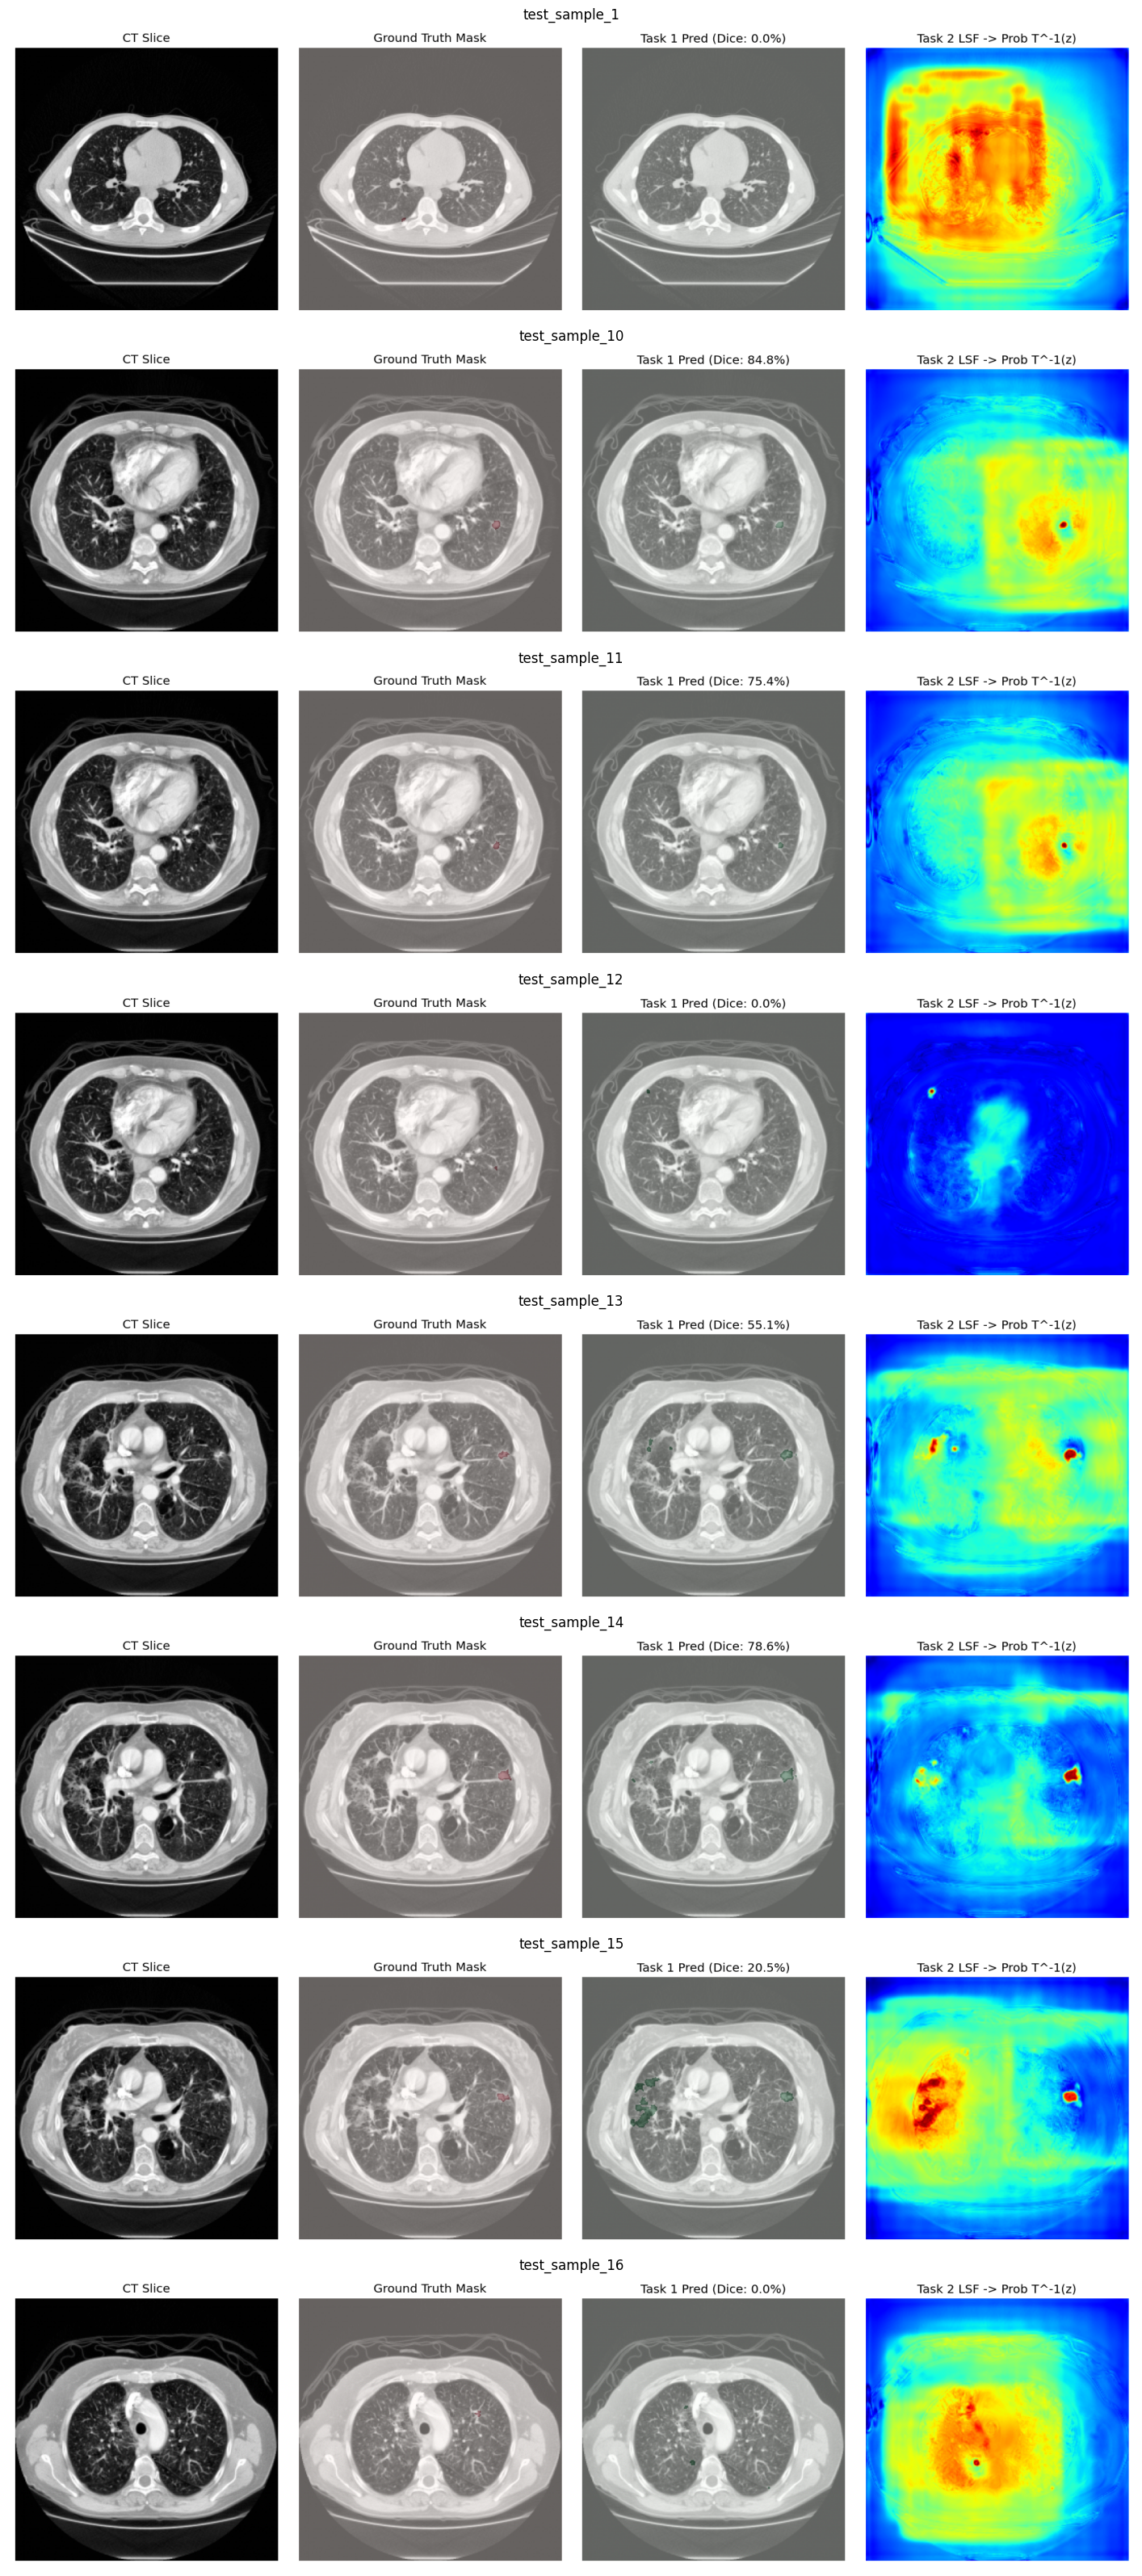

In [7]:
import glob
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

viz_files = sorted(glob.glob('/kaggle/working/evaluation_results/comparisons/*.png'))[:8]
if viz_files:
    plt.figure(figsize=(16, 4 * len(viz_files)))
    for i, f in enumerate(viz_files):
        plt.subplot(len(viz_files), 1, i + 1)
        plt.imshow(Image.open(f))
        plt.axis('off')
        plt.title(Path(f).stem, fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No comparison images found. Check /kaggle/working/evaluation_results/")
